In [1]:
!pip install wget
!pip install gensim

In [2]:
!pip install wget

In [9]:
import wget
import sys
import os

udpipe_url = 'https://rusvectores.org/static/models/udpipe_syntagrus.model'

modelfile = wget.download(udpipe_url)
print('ok')

ok


In [15]:
!pip install ufal.udpipe

# Импорт компонентов UDPipe
from ufal.udpipe import Model, Pipeline
import os
import re

   ---------------------------------------- 0.0/892.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/892.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/892.7 kB ? eta -:--:--
   ---------------------------------------- 892.7/892.7 kB 4.0 MB/s eta 0:00:00


In [13]:
def tag_ud(text='Текст нужно передать функции в виде строки!', modelfile='udpipe_syntagrus.model'):
    cnt = 0  # Счетчик строк
    udpipe_model_url = 'https://rusvectores.org/static/models/udpipe_syntagrus.model'
    udpipe_filename = udpipe_model_url.split('/')[-1]

    # Проверка и загрузка модели при необходимости
    if not os.path.isfile(modelfile):
        print('UDPipe model not found. Downloading...', file=sys.stderr)
        wget.download(udpipe_model_url)

    # Загрузка модели UDPipe
    print('\nLoading the model...', file=sys.stderr)
    model = Model.load(modelfile)
    process_pipeline = Pipeline(model, 'tokenize', Pipeline.DEFAULT, Pipeline.DEFAULT, 'conllu')

    # Обработка текста построчно
    print('Processing input...', file=sys.stderr)
    lines = text.split('\n')
    tagged = []
    for line in lines:
        output = process(process_pipeline, text=line)
        tagged_line = ' '.join(output)
        tagged.append(tagged_line)
        cnt += 1
        if cnt%1000 == 0:  # Логирование прогресса
            print(cnt)
    return '\n'.join(tagged)

In [16]:
text = open(r'skazkilem.txt', 'r', encoding='utf-8').read()
processed_text = tag_ud(text=text, modelfile=modelfile)
print(processed_text[:350])  # Просмотр первых 350 символов
with open('skazkilem.txt', 'w', encoding='utf-8') as out:
    out.write(processed_text)


Loading the model...
Processing input...


1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
шемякин_ADJ суд_NOUN

№319_NUM

в_ADP некоторый_DET палестина_NOUN два_NUM брат_NOUN живяше_ADJ единый_ADJ богатый_ADJ а_CCONJ другой_ADJ убогий_ADJ приида_NOUN убогий_ADJ брат_NOUN к_ADP богатый_ADJ лошадь_NOUN просить_PROPN  на_ADP что_PRON бы_PART он_PRON в_ADP лес_NOUN по_ADP дрова_NOUN съездить_VERB богатый_ADJ дад_NOUN он_PRON лошадь_NOUN убо


In [17]:
import sys
import gensim, logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [23]:
# Подготовка данных (одна строка - одно предложение)
f = 'skazkilem.txt'
data = gensim.models.word2vec.LineSentence(f)

In [24]:
# Установка gensim если необходимо
!pip install gensim

Инициализируем модель. Параметры в скобочках:

data - данные,
size - размер вектора,
window - размер окна наблюдения,
min_count - мин. частотность слова в корпусе, которое мы берем,
sg - используемый алгоритм обучение (0 - CBOW, 1 - Skip-gram))

In [25]:
# Обучение CBOW модели
model_CBOW = gensim.models.Word2Vec(
    data, 
    vector_size=500,  # Размерность векторов
    window=5,         # Размер окна контекста
    min_count=2,      # Минимальная частотность слова
    sg=0              # Алгоритм (0 - CBOW, 1 - Skip-gram)
)

2025-06-19 21:23:47,859 : INFO : collecting all words and their counts
2025-06-19 21:23:47,876 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-06-19 21:23:48,106 : INFO : collected 37634 word types from a corpus of 452914 raw words and 5498 sentences
2025-06-19 21:23:48,107 : INFO : Creating a fresh vocabulary
2025-06-19 21:23:48,174 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 16328 unique words (43.39% of original 37634, drops 21306)', 'datetime': '2025-06-19T21:23:48.174539', 'gensim': '4.3.3', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'prepare_vocab'}
2025-06-19 21:23:48,175 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 leaves 431608 word corpus (95.30% of original 452914, drops 21306)', 'datetime': '2025-06-19T21:23:48.175600', 'gensim': '4.3.3', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023,

In [27]:
model_CBOW.save('cbow_peter1.model')

2025-06-19 21:25:07,007 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'cbow_peter1.model', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-06-19T21:25:07.007816', 'gensim': '4.3.3', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'saving'}
2025-06-19 21:25:07,014 : INFO : not storing attribute cum_table
2025-06-19 21:25:07,132 : INFO : saved cbow_peter1.model


Загружаем сохраненную модель

In [28]:
from gensim.models import Word2Vec
cbow = Word2Vec.load('cbow_peter1.model')

2025-06-19 21:25:15,075 : INFO : loading Word2Vec object from cbow_peter1.model
2025-06-19 21:25:15,128 : INFO : loading wv recursively from cbow_peter1.model.wv.* with mmap=None
2025-06-19 21:25:15,129 : INFO : setting ignored attribute cum_table to None
2025-06-19 21:25:15,257 : INFO : Word2Vec lifecycle event {'fname': 'cbow_peter1.model', 'datetime': '2025-06-19T21:25:15.257665', 'gensim': '4.3.3', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'loaded'}


Косинусное сходство

In [80]:
# Косинусное сходство для слова "рубль"
print("CBOW similarities:")
print(cbow.wv.similarity("рубль_NOUN", "деньга_NOUN"))
print(cbow.wv.similarity("рубль_NOUN", "золото_NOUN"))
print(cbow.wv.similarity("рубль_NOUN", "сто_NOUN"))
print(cbow.wv.similarity("рубль_NOUN", "банк_NOUN"))

CBOW similarities:
0.8430076
0.74868035
0.86018586
0.80182284


In [79]:
for t in cbow.wv.most_similar(positive=[u'рубль_NOUN'], topn=20):
    print (t[0], t[1])

сто_NUM 0.9881553053855896
деньги_NOUN 0.9761838912963867
-лиходейка_NOUN 0.9728701710700989
деньги»_NOUN 0.9726158380508423
филюшка_NOUN 0.9715485572814941
эдакий_ADJ 0.9713748693466187
«одить_VERB 0.9692283272743225
«скинуть_VERB 0.9685983061790466
квакуша_NOUN 0.9672986268997192
поди_ADV 0.9671027660369873
«на_PROPN 0.9662625193595886
хозяину»_NOUN 0.9661339521408081
велеть_NOUN 0.9657225608825684
поручитель_NOUN 0.9656244516372681
буду»_NOUN 0.9652010798454285
бить_VERB 0.9651738405227661
обмануть_VERB 0.9650055766105652
твой_ADJ 0.9646419286727905
дочка_NOUN 0.9646241068840027
голод_NOUN 0.9639310240745544


Евклидово расстояние

In [83]:
# Вычисление евклидовых расстояний
import numpy as np
euclid1 = np.linalg.norm(cbow.wv['рубль_NOUN'] - cbow.wv['деньга_NOUN'])
euclid2 = np.linalg.norm(cbow.wv['рубль_NOUN'] - cbow.wv['сто_NOUN'])
print(f"\nCBOW Euclidean distances: рубль-деньга: {euclid1}, рубль-сто: {euclid2}")


CBOW Euclidean distances: рубль-деньга: 5.016807556152344, рубль-сто: 4.848892688751221


Skip-Gram

In [38]:
# Обучение Skip-Gram модели
model_sg = gensim.models.Word2Vec(data, vector_size=500, window=5, min_count=2, sg=1)
model_sg.save('skip-gram_peter1.model')
sg = Word2Vec.load('skip-gram_peter1.model')

2025-06-19 21:29:18,865 : INFO : collecting all words and their counts
2025-06-19 21:29:18,867 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-06-19 21:29:19,143 : INFO : collected 37634 word types from a corpus of 452914 raw words and 5498 sentences
2025-06-19 21:29:19,145 : INFO : Creating a fresh vocabulary
2025-06-19 21:29:19,223 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 16328 unique words (43.39% of original 37634, drops 21306)', 'datetime': '2025-06-19T21:29:19.222752', 'gensim': '4.3.3', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'prepare_vocab'}
2025-06-19 21:29:19,225 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 leaves 431608 word corpus (95.30% of original 452914, drops 21306)', 'datetime': '2025-06-19T21:29:19.225109', 'gensim': '4.3.3', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023,

In [59]:
# Тестирование Skip-Gram
for t in sg.wv.most_similar(positive=[u'рубль_NOUN'], topn=20):
    print(t[0], t[1])


сто_NUM 0.9263521432876587
тысяча_NOUN 0.8848311305046082
триста_NUM 0.884472131729126
платить_VERB 0.8706114888191223
двести_NUM 0.8701279163360596
деньг_NOUN 0.8599759340286255
покупать_VERB 0.8556678295135498
пятьдесят_NUM 0.8494313359260559
пятьсот_NUM 0.8490144610404968
долг_NOUN 0.8484429121017456
деньги_NOUN 0.8443296551704407
«давать_VERB 0.825452983379364
сотня_NOUN 0.816008448600769
рублей»_NOUN 0.810772180557251
рублев»_NOUN 0.7967869639396667
продавать_VERB 0.7967194318771362
денежка_NOUN 0.789228081703186
рублев»._NOUN 0.7824844717979431
взаймы_ADV 0.7789739966392517
«изволь_ADV 0.7745348811149597


In [60]:
model_sg.save('skip-gram_peter1.model')

2025-06-19 21:33:48,440 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'skip-gram_peter1.model', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-06-19T21:33:48.440541', 'gensim': '4.3.3', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'saving'}
2025-06-19 21:33:48,441 : INFO : not storing attribute cum_table
2025-06-19 21:33:48,572 : INFO : saved skip-gram_peter1.model


In [61]:
from gensim.models import Word2Vec
sg = Word2Vec.load('skip-gram_peter1.model')

2025-06-19 21:33:49,454 : INFO : loading Word2Vec object from skip-gram_peter1.model
2025-06-19 21:33:49,520 : INFO : loading wv recursively from skip-gram_peter1.model.wv.* with mmap=None
2025-06-19 21:33:49,522 : INFO : setting ignored attribute cum_table to None
2025-06-19 21:33:49,649 : INFO : Word2Vec lifecycle event {'fname': 'skip-gram_peter1.model', 'datetime': '2025-06-19T21:33:49.649468', 'gensim': '4.3.3', 'python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'loaded'}


In [84]:
for t in sg.wv.most_similar(positive=[u'рубль_NOUN'], topn=20):
    print (t[0], t[1])

сто_NUM 0.9263521432876587
тысяча_NOUN 0.8848311305046082
триста_NUM 0.884472131729126
платить_VERB 0.8706114888191223
двести_NUM 0.8701279163360596
деньг_NOUN 0.8599759340286255
покупать_VERB 0.8556678295135498
пятьдесят_NUM 0.8494313359260559
пятьсот_NUM 0.8490144610404968
долг_NOUN 0.8484429121017456
деньги_NOUN 0.8443296551704407
«давать_VERB 0.825452983379364
сотня_NOUN 0.816008448600769
рублей»_NOUN 0.810772180557251
рублев»_NOUN 0.7967869639396667
продавать_VERB 0.7967194318771362
денежка_NOUN 0.789228081703186
рублев»._NOUN 0.7824844717979431
взаймы_ADV 0.7789739966392517
«изволь_ADV 0.7745348811149597


In [85]:
print(sg.wv.similarity("рубль_NOUN", "деньга_NOUN"))
print(sg.wv.similarity("рубль_NOUN", "золото_NOUN"))
print(sg.wv.similarity("рубль_NOUN", "сто_NOUN"))
print(sg.wv.similarity("рубль_NOUN", "банк_NOUN"))

0.64430374
0.5392751
0.68571836
0.58186877


In [86]:
euclid3 = np.linalg.norm(sg.wv['рубль_NOUN'] - sg.wv['деньга_NOUN'])
euclid4 = np.linalg.norm(sg.wv['рубль_NOUN'] - sg.wv['сто_NOUN'])
print(f"Skip-Gram Euclidean distances: рубль-деньга: {euclid3}, рубль-сто: {euclid4}")

Skip-Gram Euclidean distances: рубль-деньга: 2.7304203510284424, рубль-сто: 2.6689202785491943


Коллокаты

In [67]:
import re

for t in sg.wv.most_similar(positive=[u'рубль_NOUN'], topn=10):
  cond = re.search(r'_(NOUN)|(ADJ)|(NUM)', t[0])
  if cond != None:
    print (t[0], t[1])

сто_NUM 0.9263521432876587
тысяча_NOUN 0.8848311305046082
триста_NUM 0.884472131729126
двести_NUM 0.8701279163360596
деньг_NOUN 0.8599759340286255
пятьдесят_NUM 0.8494313359260559
пятьсот_NUM 0.8490144610404968
долг_NOUN 0.8484429121017456


In [68]:
import re

for t in cbow.wv.most_similar(positive=[u'рубль_NOUN'], topn=10):
  cond = re.search(r'_(NOUN)|(ADJ)|(NUM)', t[0])
  if cond != None:
    print (t[0], t[1])

сто_NUM 0.9881553053855896
деньги_NOUN 0.9761838912963867
-лиходейка_NOUN 0.9728701710700989
деньги»_NOUN 0.9726158380508423
филюшка_NOUN 0.9715485572814941
эдакий_ADJ 0.9713748693466187
квакуша_NOUN 0.9672986268997192


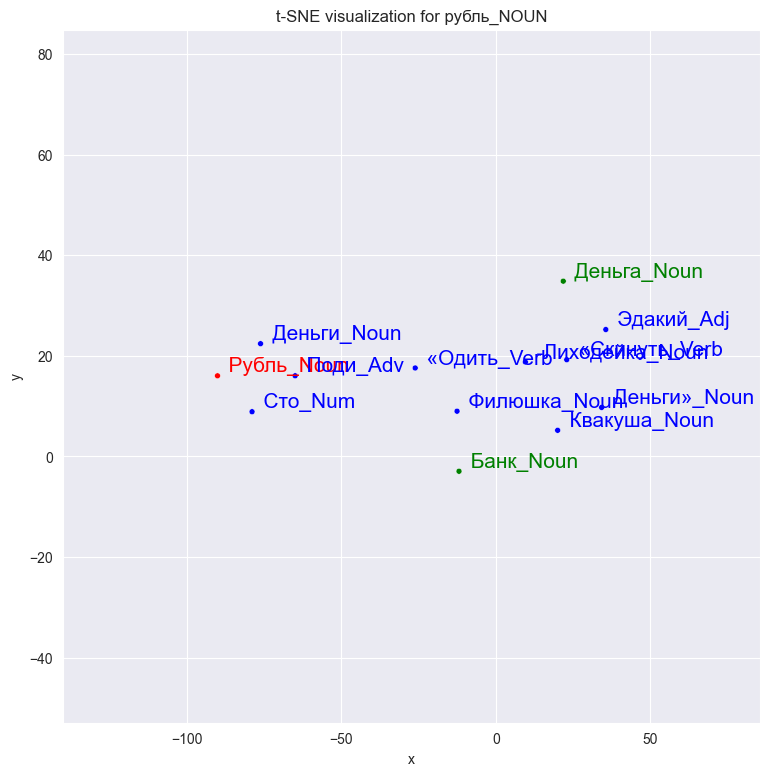

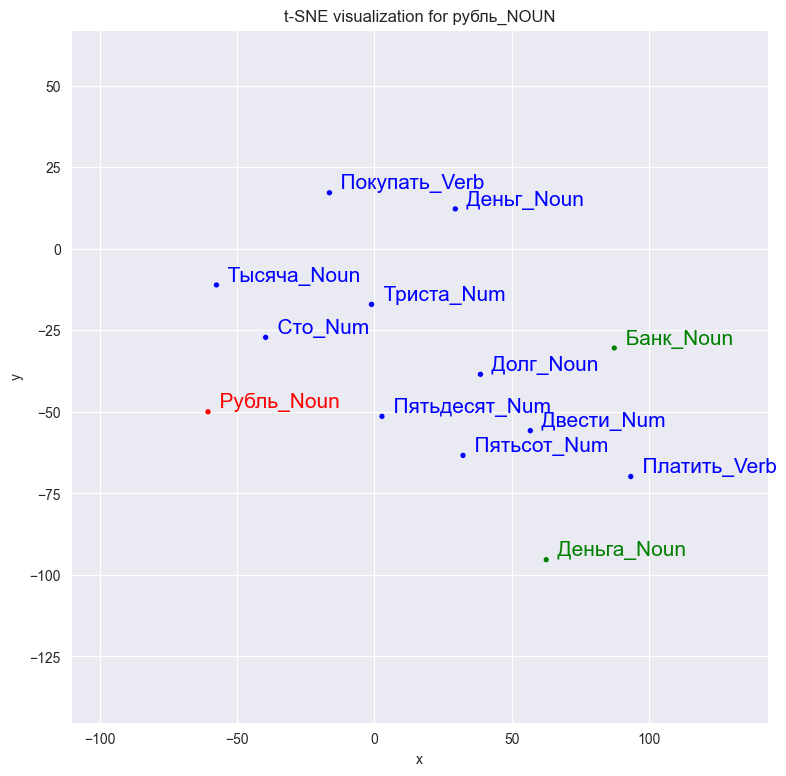

In [89]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_style("darkgrid")

def tsnescatterplot(model, word, list_names):
    # Проверка наличия целевого слова
    if word not in model.wv:
        print(f"Слово '{word}' отсутствует в словаре модели.")
        return

    arrays = np.empty((0, 500), dtype='f')
    word_labels = [word]
    color_list = ['red']

    # Добавление вектора целевого слова
    arrays = np.append(arrays, model.wv.__getitem__([word]), axis=0)

    # Получение ближайших ассоциатов
    try:
        close_words = model.wv.most_similar([word], topn=10)
    except KeyError:
        print(f"Ошибка: невозможно найти ассоциаты для '{word}'.")
        return

    # Добавление векторов ближайших ассоциатов
    for wrd_score in close_words:
        if wrd_score[0] in model.wv:
            wrd_vector = model.wv.__getitem__([wrd_score[0]])
            word_labels.append(wrd_score[0])
            color_list.append('blue')
            arrays = np.append(arrays, wrd_vector, axis=0)

    # Добавление дополнительных слов
    for wrd in list_names:
        if wrd in model.wv:
            wrd_vector = model.wv.__getitem__([wrd])
            word_labels.append(wrd)
            color_list.append('green')
            arrays = np.append(arrays, wrd_vector, axis=0)

    # Проверка количества точек
    n_samples = arrays.shape[0]
    if n_samples < 3:
        print(f"Недостаточно данных для t-SNE: только {n_samples} точек.")
        return

    # Динамическая настройка perplexity
    perplexity = min(5, n_samples - 1)  # Устанавливаем perplexity <= n_samples - 1

    try:
        # Уменьшение размерности с PCA
        reduc = PCA(n_components=min(4, n_samples)).fit_transform(arrays)

        # Применение t-SNE
        Y = TSNE(n_components=2, random_state=0, perplexity=perplexity).fit_transform(reduc)

        # Создание DataFrame
        df = pd.DataFrame({
            'x': Y[:, 0],
            'y': Y[:, 1],
            'words': word_labels,
            'color': color_list
        })

        # Визуализация
        fig, _ = plt.subplots()
        fig.set_size_inches(9, 9)

        p1 = sns.scatterplot(
            data=df, x="x", y="y", hue="color", size=40, palette=['red', 'blue', 'green'], legend=False
        )

        for i in range(df.shape[0]):
            p1.text(
                df["x"][i], df["y"][i], '  ' + df["words"][i].title(),
                horizontalalignment='left', verticalalignment='bottom', size='medium',
                color=df["color"][i], weight='normal'
            ).set_size(15)

        plt.xlim(Y[:, 0].min() - 50, Y[:, 0].max() + 50)
        plt.ylim(Y[:, 1].min() - 50, Y[:, 1].max() + 50)
        plt.title(f't-SNE visualization for {word}')
        plt.show()

    except ValueError as e:
        print(f"Ошибка при выполнении t-SNE: {e}")
        return

# Визуализация для слова "рубль"
additional_words = ['деньга_NOUN', 'валюта_NOUN', 'экономика_NOUN', 'банк_NOUN']  # Обновленный список
tsnescatterplot(cbow, 'рубль_NOUN', additional_words)
tsnescatterplot(sg, 'рубль_NOUN', additional_words)